In [ ]:
# 1. Import Required Libraries

import json
import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from tqdm import tqdm
import pandas as pd
from datetime import datetime
import argparse
from typing import Dict, List, Tuple
import os
import re
import sys

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
# 2. Model Configuration

MODEL_CONFIGS = {
    # EXAONE (LG AI Research)
    "exaone-3.5-2.4b": {
        "model_id": "LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct",
        "type": "causal",
        "max_length": 4096
    },
    # Uncomment to use larger models:
    # "exaone-3.5-7.8b": {
    #     "model_id": "LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct",
    #     "type": "causal",
    #     "max_length": 4096
    # },
    # "exaone-3.5-32b": {
    #     "model_id": "LGAI-EXAONE/EXAONE-3.5-32B-Instruct",
    #     "type": "causal",
    #     "max_length": 4096
    # },

    # Trillion Labs
    "tri-7b": {
        "model_id": "TrillionLabs/Tri-7B",
        "type": "causal",
        "max_length": 2048
    },

    # Kanana (Kakao)
    "kanana":{
        "model_id": "kakaocorp/kanana-1.5-2.1b-base",
        "type": "causal",
        "max_length": 512
    }
}

print(f"✅ Configured {len(MODEL_CONFIGS)} models:")
for model_name in MODEL_CONFIGS.keys():
    print(f"  - {model_name}")

In [ ]:
# 3. Utility Functions

def extract_choice(decoded: str, valid_choices):
    """
    Extract answer choice (A/B/C) from model output using pattern matching
    
    Args:
        decoded: Model's decoded text output
        valid_choices: List of valid answer choices
        
    Returns:
        Extracted choice or None
    """
    if not decoded:
        return None

    text = decoded.strip().upper()

    # Pattern candidates for different output formats
    patterns = [
        r"\b([ABC])\b",                         # Standalone A/B/C
        r"\bANSWER[:\s]*([ABC])\b",             # Answer: A
        r"\b정답[:\s]*([ABC])\b",               # 정답: A (Korean)
        r"\(([ABC])\)",                         # (A)
        r"\[([ABC])\]",                         # [A]
        r"([ABC])[\.\)]",                       # A. or A)
        r"\b([ABC])\s*입니다",                  # A입니다 (Korean)
        r"OPTION\s*([ABC])",                    # option A
        r"CHOICE\s*([ABC])",                    # choice B
        r"답변[:\s]*([ABC])",                   # 답변: A (Korean)
        r"ANSWER IS\s*([ABC])",                 # answer is B
        r"I CHOOSE\s*([ABC])",                  # i choose C
        r"THE ANSWER IS\s*([ABC])",             # the answer is A
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            choice = m.group(1).strip()
            if choice in valid_choices:
                return choice

    # Last fallback: check first 5 characters
    for c in valid_choices:
        if c in text[:5]:
            return c

    return None

print("✅ Utility functions defined")

## LLMBenchmark Class

The `LLMBenchmark` class handles model loading, evaluation, and entropy calculation.

### Key Components:
1. **Initialization**: Load model and tokenizer
2. **Entropy Calculation**: Full vocabulary and choice-specific entropy
3. **Prompt Generation**: Support for KoBBQ and Context3 formats
4. **Answer Generation**: With and without entropy metrics
5. **Dataset Evaluation**: Complete evaluation pipeline

In [ ]:
# 4. LLMBenchmark Class - Part 1: Initialization

class LLMBenchmark:
    def __init__(self, model_name: str, device: str = "cuda"):
        """
        Initialize LLM Benchmark evaluator
        
        Args:
            model_name: Model name from MODEL_CONFIGS
            device: 'cuda' or 'cpu' (auto-detects if CUDA unavailable)
        """
        if model_name not in MODEL_CONFIGS:
            raise ValueError(f"❌ Model '{model_name}' not found in MODEL_CONFIGS")

        self.model_name = model_name
        self.device = device if torch.cuda.is_available() else "cpu"
        self.config = MODEL_CONFIGS[model_name]

        print(f"\n📌 Loading model: {self.model_name} → {self.config['model_id']}")
        print(f"📌 Device: {self.device}")

        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(
            self.config["model_id"],
            trust_remote_code=True
        )

        # Load model based on type
        model_type = self.config.get("type", None)
        if model_type == "causal":
            self.model = AutoModelForCausalLM.from_pretrained(
                self.config["model_id"],
                torch_dtype=torch.float16 if self.device == "cuda" else torch.float32,
                device_map="auto" if self.device == "cuda" else None,
                trust_remote_code=True
            )
        elif model_type == "bert":
            self.model = AutoModelForSequenceClassification.from_pretrained(
                self.config["model_id"],
                trust_remote_code=True
            ).to(self.device)
        else:
            raise ValueError(f"❌ Unsupported model type: {model_type}")

        self.model.eval()
        print("✅ Model loaded successfully\n")

print("✅ LLMBenchmark class initialization defined")

# Korean LLM Bias Evaluation System

## 📋 Overview
This notebook provides a comprehensive evaluation system for analyzing bias in Korean Large Language Models (LLMs).

## 🎯 Supported Models
- **EXAONE 3.5** (LG AI Research): 2.4B, 7.8B, 32B parameters
- **Solar** (Kakao, Upstage): Mini (10.7B), Pro (22B)
- **Trillion Labs**: Tri-7B, Tri-21B
- **Ko-LLaMA**: 7B, 13B, 34B parameters
- **KoBERT** (SKT): 110M parameters
- **Kanana** (Kakao): 2.1B parameters

## 📊 Supported Datasets
- **KoBBQ Format**: Korean Bias Benchmark for Question Answering
- **Context3 Format**: Context-shift bias evaluation dataset

## 📈 Evaluation Metrics
- **Accuracy**: Percentage of correct answers
- **Bias Rate**: Percentage of biased responses
- **Full Entropy**: Shannon entropy over entire vocabulary
- **Choice Entropy**: Shannon entropy over answer choices (A/B/C)
- **Choice Probabilities**: Probability distribution over answer choices

## 🔧 Features
- Automatic dataset format detection
- Entropy-based confidence analysis
- Comprehensive visualization suite
- Multi-model batch evaluation
- GPU/CPU support with automatic detection

In [15]:
torch.cuda.empty_cache()

Loaded 3 result files
Loaded summary from benchmark_results_context3/benchmark_summary_data_context3.csv
Generating all visualizations...
Saved plot to visualizations/model_comparison.png


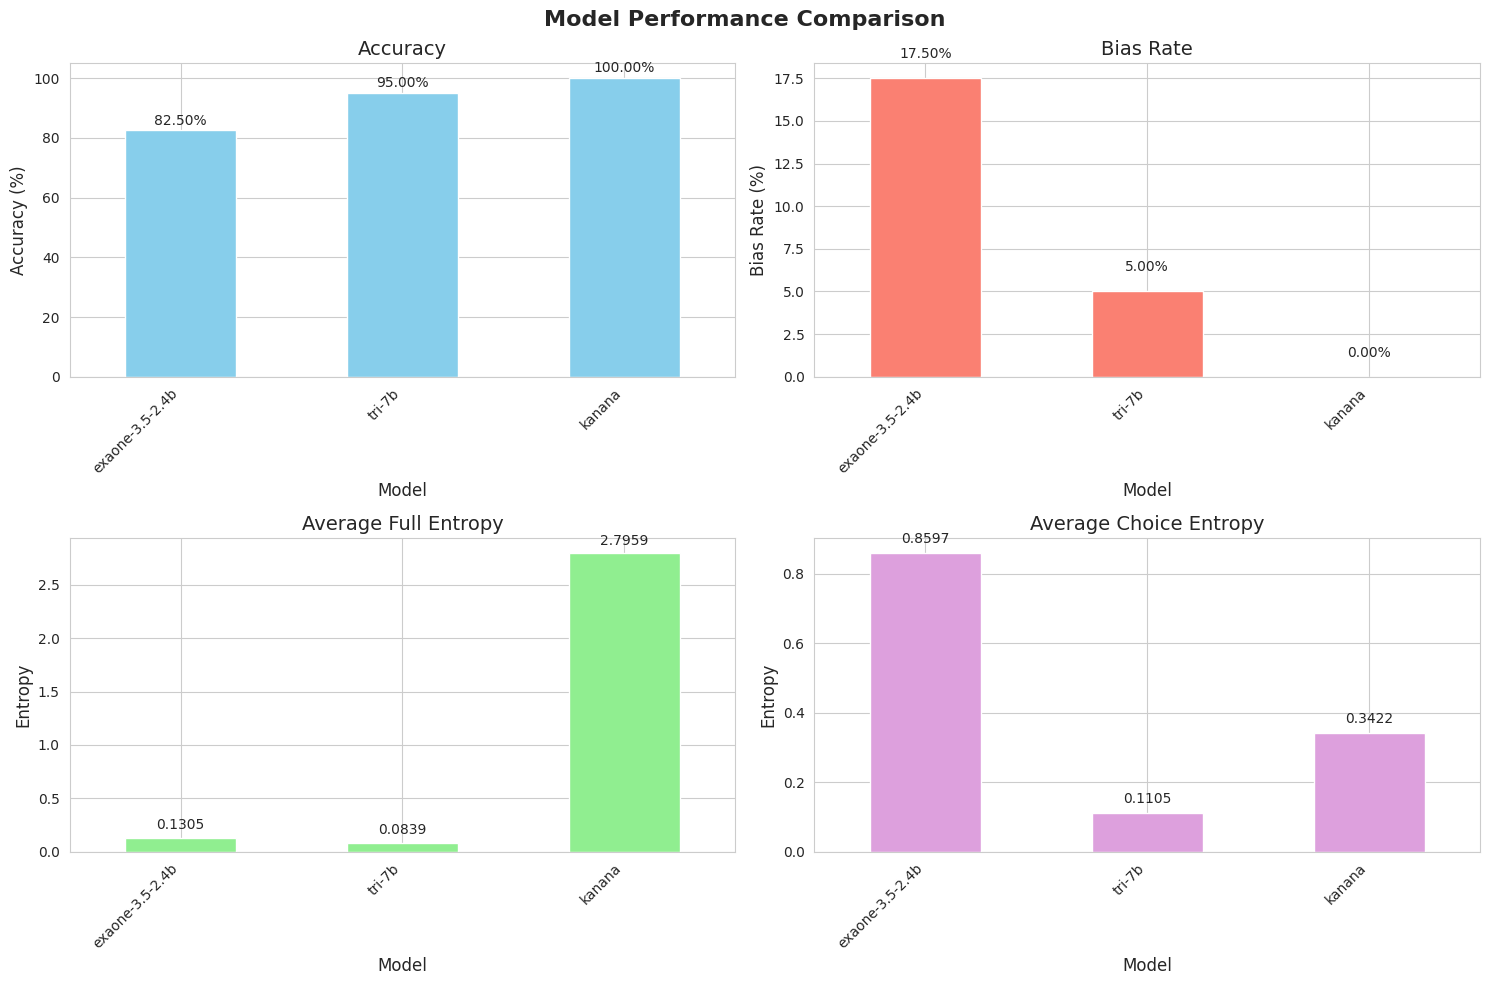

Saved plot to visualizations/radar_chart.png


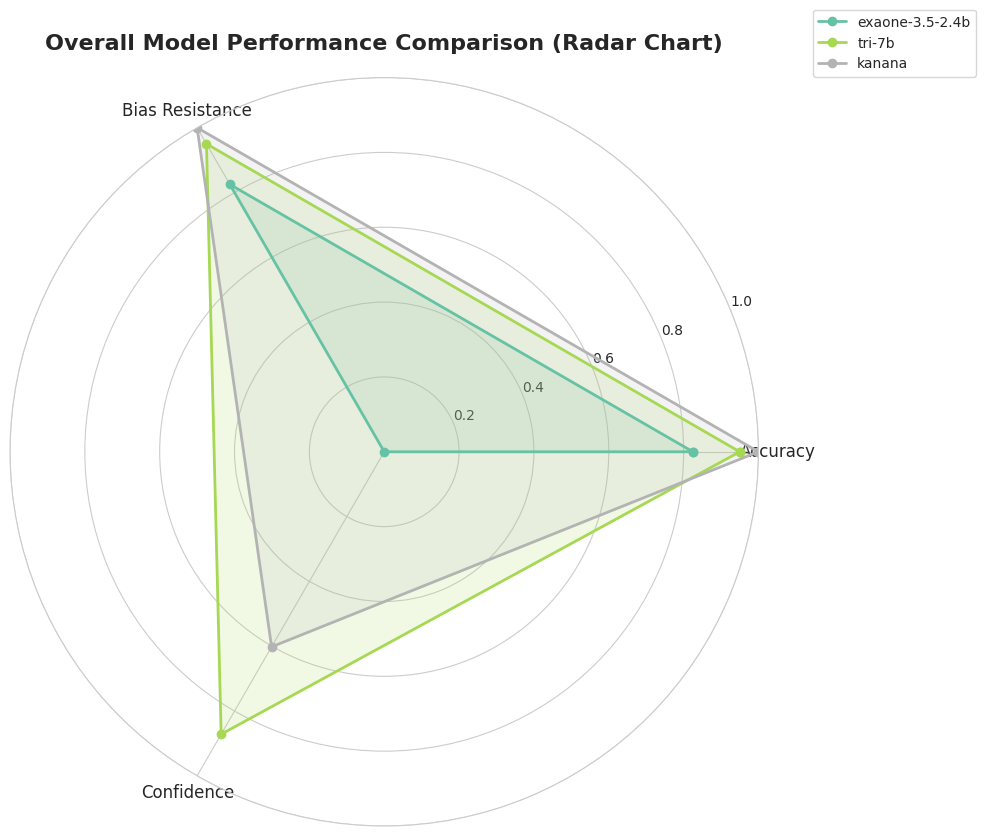

Saved plot to visualizations/entropy_accuracy_correlation.png


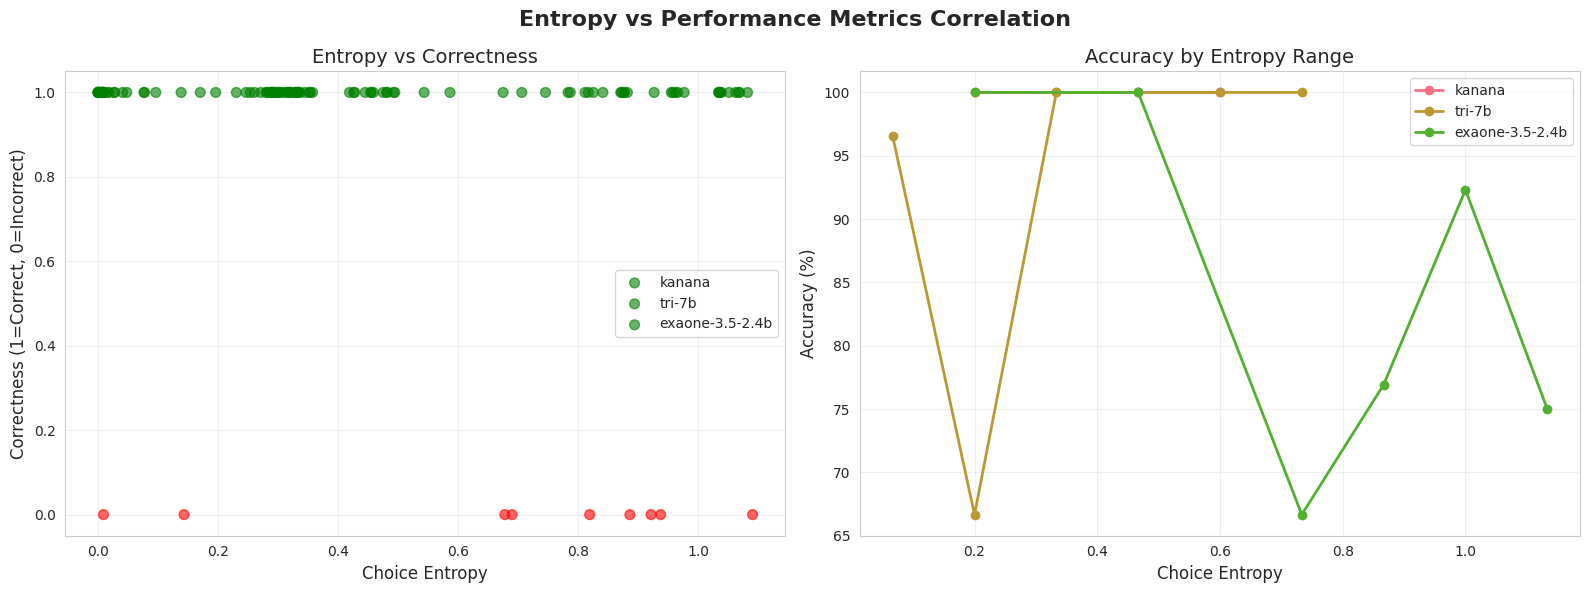


Generating plots for kanana...
Saved plot to visualizations/kanana_entropy_dist.png


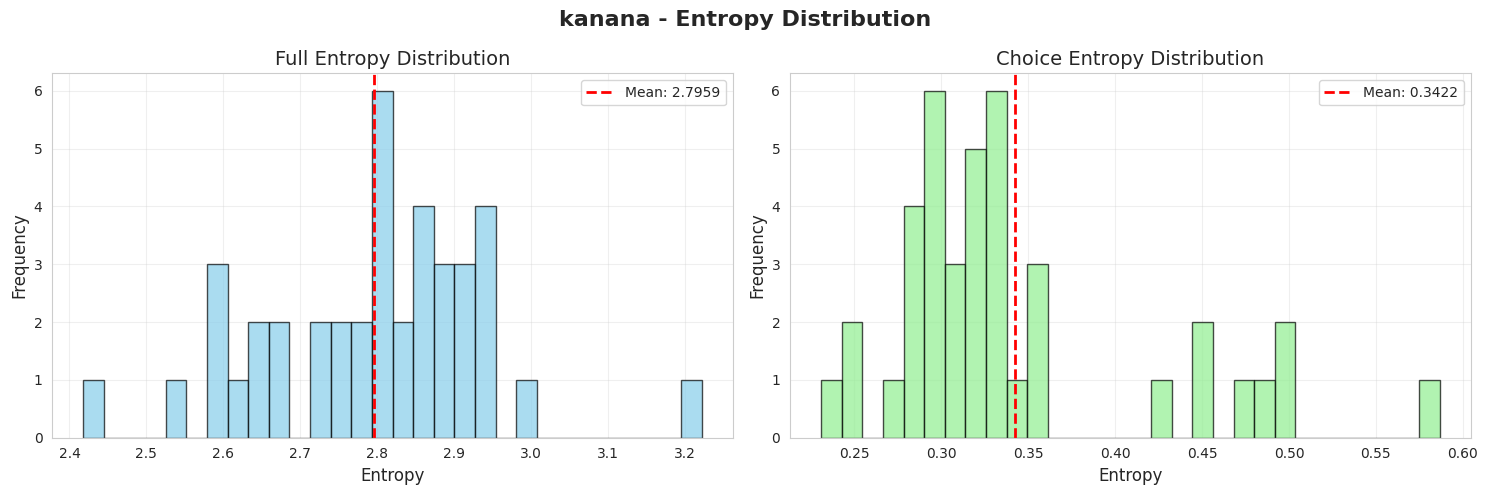

/tmp/ipython-input-1262093239.py:199: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)


ValueError: zero-size array to reduction operation minimum which has no identity

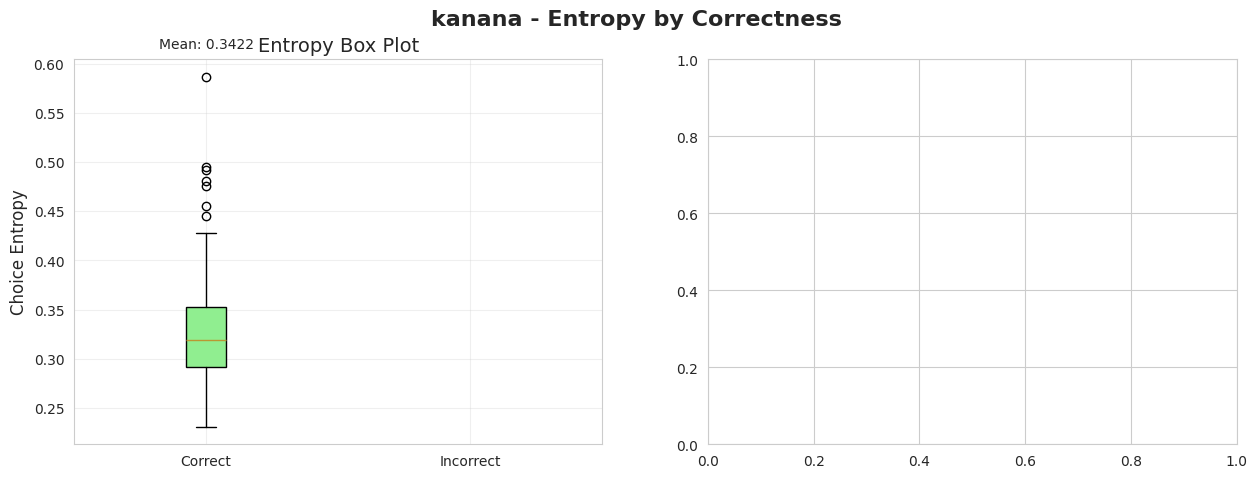

In [27]:
"""
Benchmark Results Visualization Script
"""

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import glob
from typing import List, Dict
import os

# Font settings
# Use default matplotlib fonts for English
sns.set_style("whitegrid")
sns.set_palette("husl")


class BenchmarkVisualizer:
    def __init__(self, results_dir: str = "benchmark_results_context3"):
        """
        Initialize visualization

        Args:
            results_dir: Directory where result files are stored
        """
        self.results_dir = results_dir
        self.results_data = []
        self.summary_df = None

    def load_results(self):
        """Load result JSON files"""
        json_files = glob.glob(os.path.join(self.results_dir, "*_results.json"))

        for json_file in json_files:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                self.results_data.append(data)

        print(f"Loaded {len(self.results_data)} result files")

        # Load Summary CSV
        summary_files = glob.glob(os.path.join(self.results_dir, "benchmark_summary_*.csv"))
        if summary_files:
            self.summary_df = pd.read_csv(summary_files[0], encoding='utf-8-sig')
            print(f"Loaded summary from {summary_files[0]}")

    def plot_model_comparison(self, save_path: str = None):
        """Model performance comparison chart"""
        if not self.summary_df is None and len(self.summary_df) > 0:
            # Check if entropy columns exist
            has_entropy = 'avg_full_entropy' in self.summary_df.columns and 'avg_choice_entropy' in self.summary_df.columns

            if has_entropy:
                fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            else:
                fig, axes = plt.subplots(1, 2, figsize=(15, 5))
                print("⚠️ Warning: Entropy columns not found. Showing only accuracy and bias rate.")
                print("   Run evaluation again with updated llm_evaluate.py to generate entropy data.")

            fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

            # 1. Accuracy comparison
            if has_entropy:
                ax1 = axes[0, 0]
            else:
                ax1 = axes[0]
            self.summary_df.plot(x='model_name', y='accuracy', kind='bar', ax=ax1, color='skyblue', legend=False)
            ax1.set_title('Accuracy', fontsize=14)
            ax1.set_xlabel('Model', fontsize=12)
            ax1.set_ylabel('Accuracy (%)', fontsize=12)
            ax1.set_xticklabels(self.summary_df['model_name'], rotation=45, ha='right')
            for i, v in enumerate(self.summary_df['accuracy']):
                ax1.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

            # 2. Bias Rate comparison
            if has_entropy:
                ax2 = axes[0, 1]
            else:
                ax2 = axes[1]
            self.summary_df.plot(x='model_name', y='bias_rate', kind='bar', ax=ax2, color='salmon', legend=False)
            ax2.set_title('Bias Rate', fontsize=14)
            ax2.set_xlabel('Model', fontsize=12)
            ax2.set_ylabel('Bias Rate (%)', fontsize=12)
            ax2.set_xticklabels(self.summary_df['model_name'], rotation=45, ha='right')
            for i, v in enumerate(self.summary_df['bias_rate']):
                ax2.text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

            if has_entropy:
                # 3. Average Full Entropy comparison
                ax3 = axes[1, 0]
                self.summary_df.plot(x='model_name', y='avg_full_entropy', kind='bar', ax=ax3, color='lightgreen', legend=False)
                ax3.set_title('Average Full Entropy', fontsize=14)
                ax3.set_xlabel('Model', fontsize=12)
                ax3.set_ylabel('Entropy', fontsize=12)
                ax3.set_xticklabels(self.summary_df['model_name'], rotation=45, ha='right')
                for i, v in enumerate(self.summary_df['avg_full_entropy']):
                    ax3.text(i, v + 0.05, f'{v:.4f}', ha='center', va='bottom')

                # 4. Average Choice Entropy comparison
                ax4 = axes[1, 1]
                self.summary_df.plot(x='model_name', y='avg_choice_entropy', kind='bar', ax=ax4, color='plum', legend=False)
                ax4.set_title('Average Choice Entropy', fontsize=14)
                ax4.set_xlabel('Model', fontsize=12)
                ax4.set_ylabel('Entropy', fontsize=12)
                ax4.set_xticklabels(self.summary_df['model_name'], rotation=45, ha='right')
                for i, v in enumerate(self.summary_df['avg_choice_entropy']):
                    ax4.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Saved plot to {save_path}")
            plt.show()

    def plot_entropy_distribution(self, model_name: str = None, save_path: str = None):
        """Entropy distribution visualization"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        # Extract entropy values
        full_entropies = [r['full_entropy'] for r in results if 'full_entropy' in r]
        choice_entropies = [r['choice_entropy'] for r in results if 'choice_entropy' in r]

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'{model_name} - Entropy Distribution', fontsize=16, fontweight='bold')

        # 1. Full Entropy distribution
        ax1 = axes[0]
        ax1.hist(full_entropies, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        ax1.axvline(np.mean(full_entropies), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(full_entropies):.4f}')
        ax1.set_title('Full Entropy Distribution', fontsize=14)
        ax1.set_xlabel('Entropy', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Choice Entropy distribution
        ax2 = axes[1]
        ax2.hist(choice_entropies, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        ax2.axvline(np.mean(choice_entropies), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(choice_entropies):.4f}')
        ax2.set_title('Choice Entropy Distribution', fontsize=14)
        ax2.set_xlabel('Entropy', fontsize=12)
        ax2.set_ylabel('Frequency', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_correct_vs_incorrect_entropy(self, model_name: str = None, save_path: str = None):
        """Entropy comparison by correctness"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        # Separate entropy by correct/incorrect
        correct_entropies = [r['choice_entropy'] for r in results if r.get('is_correct') == 1 and 'choice_entropy' in r]
        incorrect_entropies = [r['choice_entropy'] for r in results if r.get('is_correct') == 0 and 'choice_entropy' in r]

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'{model_name} - Entropy by Correctness', fontsize=16, fontweight='bold')

        # 1. Box Plot
        ax1 = axes[0]
        box_data = [correct_entropies, incorrect_entropies]
        bp = ax1.boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('salmon')
        ax1.set_title('Entropy Box Plot', fontsize=14)
        ax1.set_ylabel('Choice Entropy', fontsize=12)
        ax1.grid(True, alpha=0.3)

        # Add statistics
        if correct_entropies:
            ax1.text(1, max(correct_entropies) * 1.05, f'Mean: {np.mean(correct_entropies):.4f}', ha='center')
        if incorrect_entropies:
            ax1.text(2, max(incorrect_entropies) * 1.05, f'Mean: {np.mean(incorrect_entropies):.4f}', ha='center')

        # 2. Violin Plot
        ax2 = axes[1]
        parts = ax2.violinplot([correct_entropies, incorrect_entropies], positions=[1, 2], showmeans=True, showmedians=True)
        ax2.set_xticks([1, 2])
        ax2.set_xticklabels(['Correct', 'Incorrect'])
        ax2.set_title('Entropy Violin Plot', fontsize=14)
        ax2.set_ylabel('Choice Entropy', fontsize=12)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_choice_probabilities(self, model_name: str = None, num_samples: int = 20, save_path: str = None):
        """Choice probability visualization (sampled)"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results'][:num_samples]

        # Prepare data
        sample_ids = []
        probs_data = []

        for i, r in enumerate(results):
            if 'choice_probabilities' not in r:
                continue

            sample_ids.append(f"Q{i+1}")
            probs = r['choice_probabilities']

            # Handle different formats
            if isinstance(list(probs.keys())[0], str) and len(list(probs.keys())[0]) > 1:
                # Context3 format
                keys = list(probs.keys())
                probs_data.append([probs[keys[0]], probs[keys[1]], probs[keys[2]]])
            else:
                # KoBBQ format
                probs_data.append([probs.get('A', 0), probs.get('B', 0), probs.get('C', 0)])

        if not probs_data:
            print("No probability data found")
            return

        probs_array = np.array(probs_data)

        # Stacked Bar Chart
        fig, ax = plt.subplots(figsize=(15, 6))

        x = np.arange(len(sample_ids))
        width = 0.8

        colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
        labels = ['Choice 1', 'Choice 2', 'Choice 3']

        bottom = np.zeros(len(sample_ids))
        for i in range(3):
            ax.bar(x, probs_array[:, i], width, label=labels[i], bottom=bottom, color=colors[i], alpha=0.8)
            bottom += probs_array[:, i]

        ax.set_title(f'{model_name} - Choice Probability Distribution (First {num_samples} Samples)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Question Number', fontsize=12)
        ax.set_ylabel('Probability', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(sample_ids, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_category_performance(self, model_name: str = None, save_path: str = None):
        """Category-wise performance analysis"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        # Category statistics
        category_stats = {}
        for r in results:
            if 'category' in r:
                cat = r['category']
            elif 'sub_category' in r:
                cat = r['sub_category']
            else:
                cat = 'unknown'

            if cat not in category_stats:
                category_stats[cat] = {'correct': 0, 'total': 0, 'entropy': []}

            category_stats[cat]['total'] += 1
            if r.get('is_correct') == 1:
                category_stats[cat]['correct'] += 1
            if 'choice_entropy' in r:
                category_stats[cat]['entropy'].append(r['choice_entropy'])

        # Create dataframe
        categories = []
        accuracies = []
        avg_entropies = []

        for cat, stats in category_stats.items():
            categories.append(cat)
            accuracies.append((stats['correct'] / stats['total']) * 100)
            avg_entropies.append(np.mean(stats['entropy']) if stats['entropy'] else 0)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'{model_name} - Performance by Category', fontsize=16, fontweight='bold')

        # 1. Accuracy by category
        ax1 = axes[0]
        bars1 = ax1.bar(categories, accuracies, color='skyblue', edgecolor='black', alpha=0.7)
        ax1.set_title('Accuracy by Category', fontsize=14)
        ax1.set_xlabel('Category', fontsize=12)
        ax1.set_ylabel('Accuracy (%)', fontsize=12)
        ax1.set_xticklabels(categories, rotation=45, ha='right')

        for i, (bar, acc) in enumerate(zip(bars1, accuracies)):
            ax1.text(bar.get_x() + bar.get_width()/2, acc + 2, f'{acc:.1f}%', ha='center', va='bottom')

        # 2. Average entropy by category
        ax2 = axes[1]
        bars2 = ax2.bar(categories, avg_entropies, color='lightgreen', edgecolor='black', alpha=0.7)
        ax2.set_title('Average Entropy by Category', fontsize=14)
        ax2.set_xlabel('Category', fontsize=12)
        ax2.set_ylabel('Average Entropy', fontsize=12)
        ax2.set_xticklabels(categories, rotation=45, ha='right')

        for i, (bar, ent) in enumerate(zip(bars2, avg_entropies)):
            ax2.text(bar.get_x() + bar.get_width()/2, ent + 0.02, f'{ent:.4f}', ha='center', va='bottom')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_entropy_vs_accuracy_scatter(self, save_path: str = None):
        """Scatter plot of entropy vs accuracy correlation"""
        if not self.results_data:
            print("No results loaded")
            return

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Entropy vs Performance Metrics Correlation', fontsize=16, fontweight='bold')

        for data in self.results_data:
            model_name = data['model_name']
            results = data['results']

            choice_entropies = []
            is_correct_list = []
            is_bias_list = []

            for r in results:
                if 'choice_entropy' in r:
                    choice_entropies.append(r['choice_entropy'])
                    is_correct_list.append(r.get('is_correct', 0))
                    is_bias_list.append(r.get('is_bias', 0))

            # 1. Entropy vs correctness
            ax1 = axes[0]
            colors = ['green' if c else 'red' for c in is_correct_list]
            ax1.scatter(choice_entropies, is_correct_list, alpha=0.6, c=colors, s=50, label=model_name)

        axes[0].set_title('Entropy vs Correctness', fontsize=14)
        axes[0].set_xlabel('Choice Entropy', fontsize=12)
        axes[0].set_ylabel('Correctness (1=Correct, 0=Incorrect)', fontsize=12)
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # 2. Accuracy by entropy bins
        ax2 = axes[1]
        for data in self.results_data:
            model_name = data['model_name']
            results = data['results']

            entropy_bins = np.linspace(0, 1.2, 10)
            bin_accuracies = []
            bin_centers = []

            for i in range(len(entropy_bins) - 1):
                bin_samples = [r for r in results if 'choice_entropy' in r and
                              entropy_bins[i] <= r['choice_entropy'] < entropy_bins[i+1]]

                if bin_samples:
                    accuracy = sum(r.get('is_correct', 0) for r in bin_samples) / len(bin_samples) * 100
                    bin_accuracies.append(accuracy)
                    bin_centers.append((entropy_bins[i] + entropy_bins[i+1]) / 2)

            ax2.plot(bin_centers, bin_accuracies, marker='o', label=model_name, linewidth=2)

        ax2.set_title('Accuracy by Entropy Range', fontsize=14)
        ax2.set_xlabel('Choice Entropy', fontsize=12)
        ax2.set_ylabel('Accuracy (%)', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_confusion_heatmap(self, model_name: str = None, save_path: str = None):
        """Confusion matrix heatmap"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        # Create confusion matrix
        confusion_matrix = np.zeros((3, 3))
        labels = ['A', 'B', 'C']

        for r in results:
            if 'ground_truth' in r and 'model_answer' in r:
                gt = r['ground_truth']
                pred = r.get('model_answer', 'C')

                if gt in labels and pred in labels:
                    gt_idx = labels.index(gt)
                    pred_idx = labels.index(pred)
                    confusion_matrix[gt_idx][pred_idx] += 1

        # Normalize
        row_sums = confusion_matrix.sum(axis=1, keepdims=True)
        confusion_matrix_normalized = np.divide(confusion_matrix, row_sums,
                                                where=row_sums!=0,
                                                out=np.zeros_like(confusion_matrix))

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')

        # 1. Absolute values heatmap
        ax1 = axes[0]
        sns.heatmap(confusion_matrix, annot=True, fmt='.0f', cmap='Blues',
                   xticklabels=labels, yticklabels=labels, ax=ax1, cbar_kws={'label': 'Count'})
        ax1.set_title('Confusion Matrix (Absolute)', fontsize=14)
        ax1.set_xlabel('Predicted Answer', fontsize=12)
        ax1.set_ylabel('Ground Truth', fontsize=12)

        # 2. Normalized heatmap
        ax2 = axes[1]
        sns.heatmap(confusion_matrix_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
                   xticklabels=labels, yticklabels=labels, ax=ax2, vmin=0, vmax=1,
                   cbar_kws={'label': 'Ratio'})
        ax2.set_title('Confusion Matrix (Normalized)', fontsize=14)
        ax2.set_xlabel('Predicted Answer', fontsize=12)
        ax2.set_ylabel('Ground Truth', fontsize=12)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_radar_chart(self, save_path: str = None):
        """Radar chart of overall model performance"""
        if not self.summary_df is None and len(self.summary_df) > 0:
            # Check if entropy column exists
            has_entropy = 'avg_choice_entropy' in self.summary_df.columns

            if not has_entropy:
                print("⚠️ Warning: Entropy data not found. Cannot generate radar chart.")
                print("   Run evaluation again with updated llm_evaluate.py to generate entropy data.")
                return

            # Normalize metrics (0~1 scale)
            df_normalized = self.summary_df.copy()
            df_normalized['accuracy_norm'] = df_normalized['accuracy'] / 100
            df_normalized['bias_rate_norm'] = 1 - (df_normalized['bias_rate'] / 100)
            df_normalized['entropy_norm'] = 1 - (df_normalized['avg_choice_entropy'] / df_normalized['avg_choice_entropy'].max())

            categories = ['Accuracy', 'Bias Resistance', 'Confidence']

            # Radar chart setup
            num_vars = len(categories)
            angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
            angles += angles[:1]

            _, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

            colors = plt.cm.Set2(np.linspace(0, 1, len(df_normalized)))

            for idx, row in df_normalized.iterrows():
                values = [row['accuracy_norm'], row['bias_rate_norm'], row['entropy_norm']]
                values += values[:1]

                ax.plot(angles, values, 'o-', linewidth=2, label=row['model_name'], color=colors[idx])
                ax.fill(angles, values, alpha=0.15, color=colors[idx])

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(categories, size=12)
            ax.set_ylim(0, 1)
            ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
            ax.grid(True)
            ax.set_title('Overall Model Performance Comparison (Radar Chart)', size=16, fontweight='bold', pad=20)
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

            plt.tight_layout()

            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Saved plot to {save_path}")
            plt.show()

    def plot_bias_pattern_analysis(self, model_name: str = None, save_path: str = None):
        """Bias pattern analysis"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        biased_samples = [r for r in results if r.get('is_bias') == 1]

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'{model_name} - Bias Pattern Analysis', fontsize=16, fontweight='bold')

        # 1. Answer distribution
        ax1 = axes[0, 0]
        answer_counts = {'A': 0, 'B': 0, 'C': 0}
        for r in results:
            ans = r.get('model_answer', 'C')
            if ans in answer_counts:
                answer_counts[ans] += 1

        ax1.bar(answer_counts.keys(), answer_counts.values(), color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
        ax1.set_title('Model Answer Distribution', fontsize=14)
        ax1.set_xlabel('Answer', fontsize=12)
        ax1.set_ylabel('Frequency', fontsize=12)
        for i, (k, v) in enumerate(answer_counts.items()):
            ax1.text(i, v + 1, str(v), ha='center', va='bottom')

        # 2. Entropy distribution by bias
        ax2 = axes[0, 1]
        biased_entropies = [r['choice_entropy'] for r in biased_samples if 'choice_entropy' in r]
        unbiased_entropies = [r['choice_entropy'] for r in results if r.get('is_bias') == 0 and 'choice_entropy' in r]

        ax2.hist([biased_entropies, unbiased_entropies], bins=20, label=['Biased', 'Unbiased'],
                color=['salmon', 'lightblue'], alpha=0.7)
        ax2.set_title('Entropy Distribution by Bias', fontsize=14)
        ax2.set_xlabel('Entropy', fontsize=12)
        ax2.set_ylabel('Frequency', fontsize=12)
        ax2.legend()

        # 3. Pie chart of correct/incorrect/bias
        ax3 = axes[1, 0]
        correct_not_bias = len([r for r in results if r.get('is_correct') == 1 and r.get('is_bias') == 0])
        incorrect_bias = len([r for r in results if r.get('is_correct') == 0 and r.get('is_bias') == 1])
        incorrect_not_bias = len([r for r in results if r.get('is_correct') == 0 and r.get('is_bias') == 0])

        sizes = [correct_not_bias, incorrect_bias, incorrect_not_bias]
        labels_pie = [f'Correct\n(Unbiased)\n{correct_not_bias}',
                     f'Incorrect\n(Biased)\n{incorrect_bias}',
                     f'Incorrect\n(Unbiased)\n{incorrect_not_bias}']
        colors = ['#90EE90', '#FF6B6B', '#FFD700']

        ax3.pie(sizes, labels=labels_pie, colors=colors, autopct='%1.1f%%', startangle=90)
        ax3.set_title('Correct/Incorrect/Bias Distribution', fontsize=14)

        # 4. Average probability by answer type
        ax4 = axes[1, 1]

        correct_probs = {'A': [], 'B': [], 'C': []}
        incorrect_probs = {'A': [], 'B': [], 'C': []}
        biased_probs = {'A': [], 'B': [], 'C': []}

        for r in results:
            if 'choice_probabilities' not in r:
                continue

            probs = r['choice_probabilities']
            if isinstance(list(probs.keys())[0], str) and len(list(probs.keys())[0]) > 1:
                continue

            if r.get('is_correct') == 1:
                for k in ['A', 'B', 'C']:
                    if k in probs:
                        correct_probs[k].append(probs[k])
            elif r.get('is_bias') == 1:
                for k in ['A', 'B', 'C']:
                    if k in probs:
                        biased_probs[k].append(probs[k])
            else:
                for k in ['A', 'B', 'C']:
                    if k in probs:
                        incorrect_probs[k].append(probs[k])

        x = np.arange(3)
        width = 0.25

        correct_means = [np.mean(correct_probs[k]) if correct_probs[k] else 0 for k in ['A', 'B', 'C']]
        biased_means = [np.mean(biased_probs[k]) if biased_probs[k] else 0 for k in ['A', 'B', 'C']]
        incorrect_means = [np.mean(incorrect_probs[k]) if incorrect_probs[k] else 0 for k in ['A', 'B', 'C']]

        ax4.bar(x - width, correct_means, width, label='Correct', color='lightgreen')
        ax4.bar(x, biased_means, width, label='Biased', color='salmon')
        ax4.bar(x + width, incorrect_means, width, label='Incorrect (Unbiased)', color='gold')

        ax4.set_title('Average Choice Probability by Answer Type', fontsize=14)
        ax4.set_xlabel('Choice', fontsize=12)
        ax4.set_ylabel('Average Probability', fontsize=12)
        ax4.set_xticks(x)
        ax4.set_xticklabels(['A', 'B', 'C'])
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def plot_sample_difficulty_analysis(self, model_name: str = None, save_path: str = None):
        """Sample difficulty analysis (entropy-based)"""
        if not self.results_data:
            print("No results loaded")
            return

        if model_name:
            data = next((d for d in self.results_data if d['model_name'] == model_name), None)
        else:
            data = self.results_data[0]
            model_name = data['model_name']

        if not data:
            print(f"Model {model_name} not found")
            return

        results = data['results']

        # Classify difficulty by entropy
        entropies_with_correctness = [(r['choice_entropy'], r.get('is_correct', 0), i)
                                      for i, r in enumerate(results) if 'choice_entropy' in r]
        entropies_with_correctness.sort()

        # 3 difficulty levels
        n = len(entropies_with_correctness)
        easy = entropies_with_correctness[:n//3]
        medium = entropies_with_correctness[n//3:2*n//3]
        hard = entropies_with_correctness[2*n//3:]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'{model_name} - Sample Difficulty Analysis (Entropy-based)', fontsize=16, fontweight='bold')

        # 1. Accuracy by difficulty
        ax1 = axes[0]
        difficulties = ['Easy\n(Low Entropy)', 'Medium', 'Hard\n(High Entropy)']
        accuracies = [
            sum(c for _, c, _ in easy) / len(easy) * 100 if easy else 0,
            sum(c for _, c, _ in medium) / len(medium) * 100 if medium else 0,
            sum(c for _, c, _ in hard) / len(hard) * 100 if hard else 0
        ]

        bars = ax1.bar(difficulties, accuracies, color=['#90EE90', '#FFD700', '#FF6B6B'])
        ax1.set_title('Accuracy by Difficulty', fontsize=14)
        ax1.set_ylabel('Accuracy (%)', fontsize=12)
        ax1.set_ylim(0, 100)

        for bar, acc in zip(bars, accuracies):
            ax1.text(bar.get_x() + bar.get_width()/2, acc + 2, f'{acc:.1f}%',
                    ha='center', va='bottom', fontweight='bold')

        # 2. Entropy range by difficulty
        ax2 = axes[1]
        entropy_ranges = [
            [e for e, _, _ in easy],
            [e for e, _, _ in medium],
            [e for e, _, _ in hard]
        ]

        bp = ax2.boxplot(entropy_ranges, labels=['Easy', 'Medium', 'Hard'], patch_artist=True)
        colors = ['#90EE90', '#FFD700', '#FF6B6B']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        ax2.set_title('Entropy Distribution by Difficulty', fontsize=14)
        ax2.set_ylabel('Choice Entropy', fontsize=12)
        ax2.grid(True, alpha=0.3, axis='y')

        # 3. Scatter plot with difficulty colors
        ax3 = axes[2]

        for samples, color, label in [(easy, '#90EE90', 'Easy'),
                                      (medium, '#FFD700', 'Medium'),
                                      (hard, '#FF6B6B', 'Hard')]:
            entropies = [e for e, _, _ in samples]
            correctness = [c for _, c, _ in samples]
            jitter = np.random.normal(0, 0.02, len(correctness))
            ax3.scatter(entropies, np.array(correctness) + jitter, alpha=0.6, s=50,
                       c=color, label=label, edgecolors='black', linewidth=0.5)

        ax3.set_title('Entropy vs Correctness (by Difficulty)', fontsize=14)
        ax3.set_xlabel('Choice Entropy', fontsize=12)
        ax3.set_ylabel('Correctness', fontsize=12)
        ax3.set_yticks([0, 1])
        ax3.set_yticklabels(['Incorrect', 'Correct'])
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        plt.show()

    def generate_all_plots(self, output_dir: str = "visualizations"):
        """Generate all visualizations"""
        os.makedirs(output_dir, exist_ok=True)

        print("Generating all visualizations...")

        # 1. Model comparison
        self.plot_model_comparison(save_path=os.path.join(output_dir, "model_comparison.png"))

        # 2. Radar chart
        self.plot_radar_chart(save_path=os.path.join(output_dir, "radar_chart.png"))

        # 3. Entropy-accuracy correlation
        self.plot_entropy_vs_accuracy_scatter(save_path=os.path.join(output_dir, "entropy_accuracy_correlation.png"))

        # 4. Detailed analysis per model
        for data in self.results_data:
            model_name = data['model_name']
            print(f"\nGenerating plots for {model_name}...")

            # Entropy distribution
            self.plot_entropy_distribution(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_entropy_dist.png")
            )

            # Correct vs incorrect entropy
            self.plot_correct_vs_incorrect_entropy(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_correct_vs_incorrect.png")
            )

            # Choice probabilities
            self.plot_choice_probabilities(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_choice_probs.png")
            )

            # Category performance
            self.plot_category_performance(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_category_performance.png")
            )

            # Confusion matrix
            self.plot_confusion_heatmap(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_confusion_matrix.png")
            )

            # Bias pattern
            self.plot_bias_pattern_analysis(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_bias_pattern.png")
            )

            # Difficulty analysis
            self.plot_sample_difficulty_analysis(
                model_name=model_name,
                save_path=os.path.join(output_dir, f"{model_name}_difficulty_analysis.png")
            )

        print(f"\nAll visualizations saved to {output_dir}/")


# Usage example
if __name__ == "__main__":
    # Create visualizer object
    viz = BenchmarkVisualizer("benchmark_results_context3")

    # Load results
    viz.load_results()

    # Generate all visualizations
    viz.generate_all_plots(output_dir="visualizations")


Loaded 5 result files
Loaded summary from benchmark_results_context3/benchmark_summary_data_context3.csv

사용 가능한 시각화 함수:
1. viz.plot_model_comparison()           - 모델 간 성능 비교
2. viz.plot_entropy_distribution()       - 엔트로피 분포
3. viz.plot_correct_vs_incorrect_entropy() - 정답/오답 엔트로피 비교
4. viz.plot_choice_probabilities()       - 선택지 확률 분포
5. viz.plot_category_performance()       - 카테고리별 성능
6. viz.generate_all_plots()              - 모든 시각화 생성


KeyError: 'avg_full_entropy'

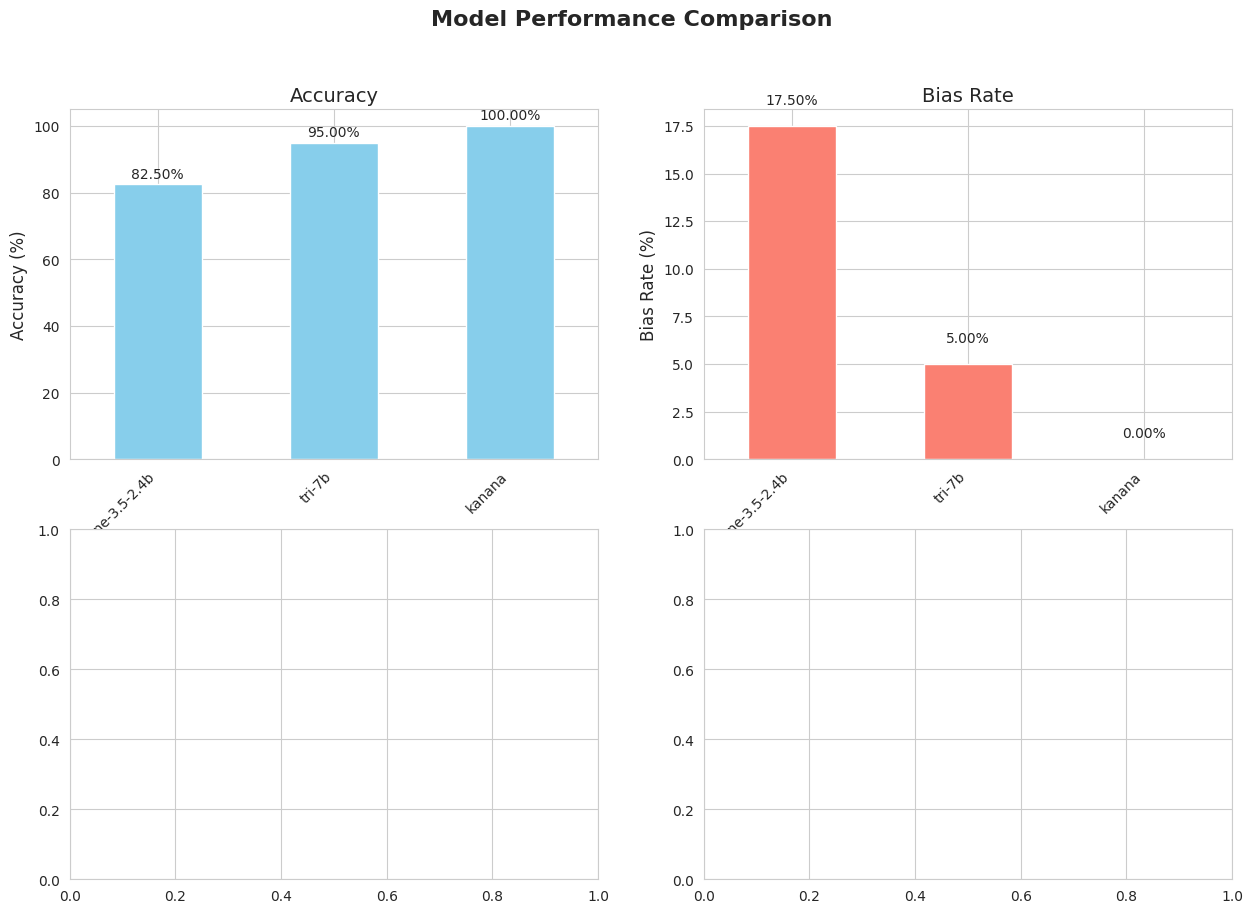

In [22]:
"""
결과 시각화
"""
import glob
import matplotlib.pyplot as plt

# 시각화 객체 생성
viz = BenchmarkVisualizer("benchmark_results_context3")

# 결과 로드
viz.load_results()

print("\n" + "="*60)
print("사용 가능한 시각화 함수:")
print("="*60)
print("1. viz.plot_model_comparison()           - 모델 간 성능 비교")
print("2. viz.plot_entropy_distribution()       - 엔트로피 분포")
print("3. viz.plot_correct_vs_incorrect_entropy() - 정답/오답 엔트로피 비교")
print("4. viz.plot_choice_probabilities()       - 선택지 확률 분포")
print("5. viz.plot_category_performance()       - 카테고리별 성능")
print("6. viz.generate_all_plots()              - 모든 시각화 생성")
print("="*60)

# 예시: 모델 비교 시각화
viz.plot_model_comparison()
